#Healthcare Analytics for Doctor Visits

##Problem Statement

Healthcare providers need to understand who visits doctors, how often, and why, so they can plan capacity and target high-need groups. Using survey data on 5,190 individuals, this project analyses how demographics, income, insurance and health status relate to the number of doctor visits in a 2-week period.

## Dataset Overview
This dataset contains information about people, their health conditions, healthcare
support and the number of times they visited a doctor in a 2-week period. The purpose
is to explore patterns and understand which factors may be associated with doctor visits.

**Core question:** Why do some people visit a doctor more often than others?

## Dataset Columns
| Column | Meaning |
|---|---|
| visits | Doctor visits in past 2 weeks (target) |
| gender, age, income | Demographics (age = age/100, income in A$10,000s) |
| illness | Number of illnesses in past 2 weeks |
| reduced | Days of reduced activity due to illness |
| health | General health score (higher = worse) |
| private | Private health insurance |
| freepoor / freerepat | Free government cover (low income / repatriation) |
| nchronic / lchronic | Chronic condition without / with activity limitation |

## Main Objective
The main objective is to analyse patient-related information and identify useful
patterns in doctor visits. Age, health condition, illness, income, chronic conditions
and healthcare support (insurance) are each compared with the number of visits.

## Key Questions
1. How many people visited a doctor?
2. Which age group visits most?
3. Does income affect visits?
4. Does insurance type affect visits?
5. Do chronic conditions increase visits?
6. Do reduced-activity days increase visits?
7. Does a worse health score increase visits?
8. Which factors correlate most with visits?
9. Who are the high users?
10. Do men and women differ with a limiting chronic condition?

In [43]:
#Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
#Load datas
df=pd.read_csv("/content/Healthcare_Analytics_for_Doctor_Visits__.csv")

In [48]:
#top 5 rows
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [49]:
#last 5 rows
df.tail()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


In [50]:
# remove the extra index column
df = df.drop(columns=["Unnamed: 0"])

In [51]:
#top 5 rows
df.head()

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [52]:
#last 5 rows
df.tail()

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


In [53]:
#Number of rows and columns
df.shape

(5190, 12)

In [54]:
#Columns Informations
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   visits     5190 non-null   int64  
 1   gender     5190 non-null   object 
 2   age        5190 non-null   float64
 3   income     5190 non-null   float64
 4   illness    5190 non-null   int64  
 5   reduced    5190 non-null   int64  
 6   health     5190 non-null   int64  
 7   private    5190 non-null   object 
 8   freepoor   5190 non-null   object 
 9   freerepat  5190 non-null   object 
 10  nchronic   5190 non-null   object 
 11  lchronic   5190 non-null   object 
dtypes: float64(2), int64(4), object(6)
memory usage: 486.7+ KB


In [55]:
#stastical inforamation of the dataset
df.describe()

,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [56]:
#Checking the null values
df.isnull().sum()

,0
visits,0
gender,0
age,0
income,0
illness,0
reduced,0
health,0
private,0
freepoor,0
freerepat,0


#Duplicate Values
Duplicate rows are checked below. They are **retained** because this is survey data where different respondents can give identical answers, so they are not data-entry errors. Most duplicates are healthy people with 0 visits, so removing them would bias the results.

In [57]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate %:", round(df.duplicated().mean() * 100, 2))

Duplicate rows: 1320
Duplicate %: 25.43


In [58]:
# are the duplicates mostly zero-visit people?
print(df[df.duplicated(keep=False)]["visits"].value_counts().sort_index())

visits
0    1795
1      97
2       2
Name: count, dtype: int64


In [59]:
# effect of dropping duplicates on average visits
print("Mean visits (all rows):", round(df["visits"].mean(), 3))
print("Mean visits (no duplicates):", round(df.drop_duplicates()["visits"].mean(), 3))

Mean visits (all rows): 0.302
Mean visits (no duplicates): 0.389


## 3. Univariate Analysis

###Gender distribution

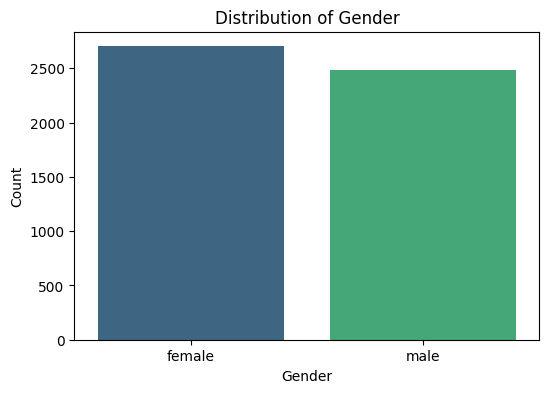

In [29]:
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', data=df, palette='viridis', hue='gender', legend=False)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

###Age distribution

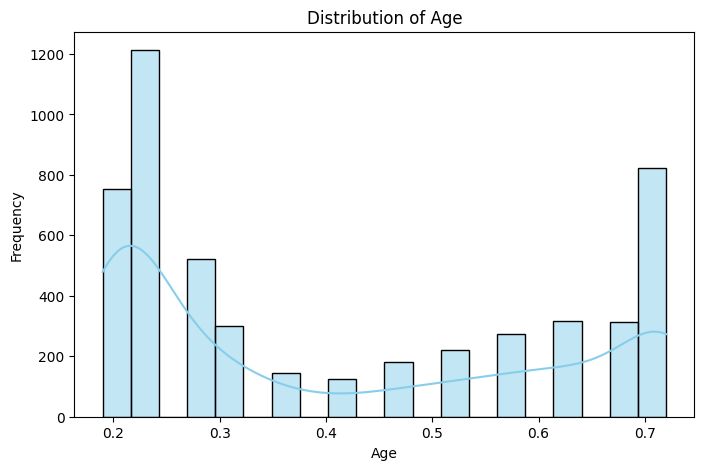

In [30]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

###Doctor visits distribution

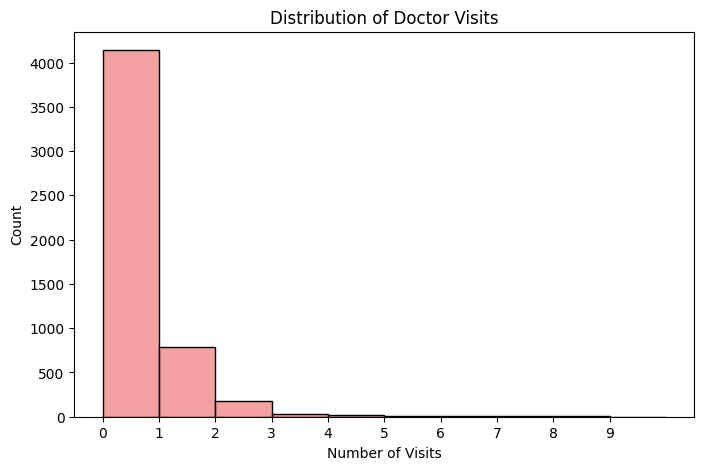

In [31]:
plt.figure(figsize=(8, 5))
sns.histplot(df['visits'], bins=range(int(df['visits'].max()) + 2), kde=False, color='lightcoral', stat='count')
plt.title('Distribution of Doctor Visits')
plt.xlabel('Number of Visits')
plt.ylabel('Count')
plt.xticks(range(int(df['visits'].max()) + 1))
plt.show()

### Visited Doctor vs Did Not Visit

any_visit
0    4141
1    1049
Name: count, dtype: int64
any_visit
0    79.788054
1    20.211946
Name: proportion, dtype: float64


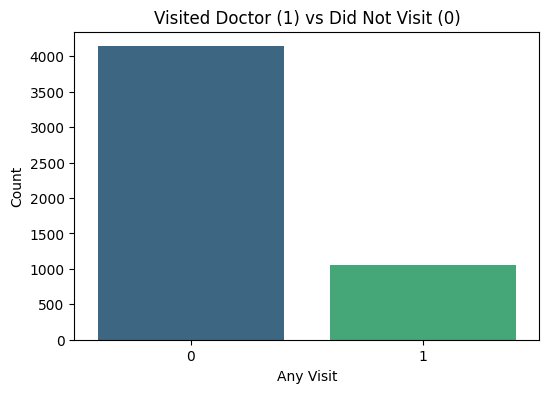

In [60]:
# new column: 1 if the person visited a doctor at least once, else 0
df["any_visit"] = (df["visits"] > 0).astype(int)

print(df["any_visit"].value_counts())
print(df["any_visit"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x="any_visit", data=df, hue="any_visit", palette="viridis", legend=False)
plt.title("Visited Doctor (1) vs Did Not Visit (0)")
plt.xlabel("Any Visit")
plt.ylabel("Count")
plt.show()

**Finding:** about 80% of people had zero visits, and most of the visits come from a small group.

##Bivariate analysis

###Visits by Gender

,gender,count,mean,median
0,female,2702,0.361954,0.0
1,male,2488,0.236334,0.0


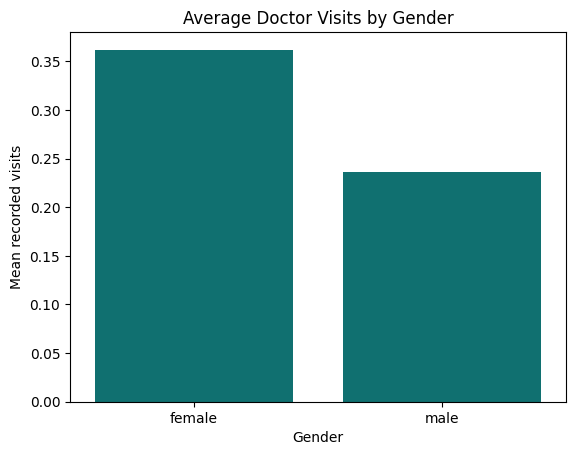

In [32]:
gender_analysis = (
    df.groupby("gender")["visits"]
      .agg(["count", "mean", "median"])
      .reset_index()
)

display(gender_analysis)

sns.barplot(
    data=gender_analysis,
    x="gender",
    y="mean",
    color="teal"
)

plt.title("Average Doctor Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean recorded visits")
plt.show()

###Illness Score vs. Average Doctor Visits

,illness,count,mean
0,0,1554,0.078507
1,1,1638,0.295482
2,2,946,0.403805
3,3,542,0.420664
4,4,274,0.576642
5,5,236,0.813559


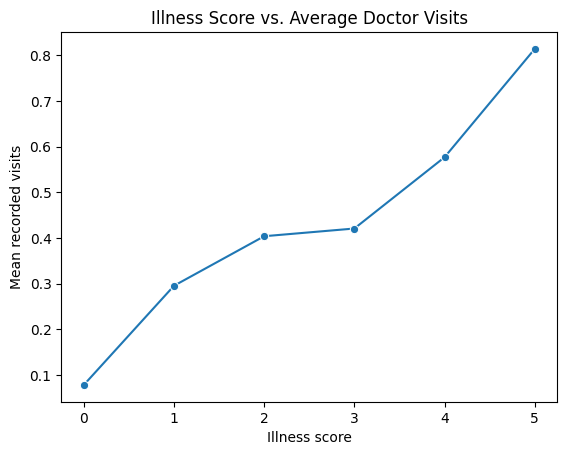

In [34]:
illness_analysis = (
    df.groupby("illness")["visits"]
      .agg(["count", "mean"])
      .reset_index()
)

display(illness_analysis)

sns.lineplot(
    data=illness_analysis,
    x="illness",
    y="mean",
    marker="o"
)

plt.title("Illness Score vs. Average Doctor Visits")
plt.xlabel("Illness score")
plt.ylabel("Mean recorded visits")
plt.show()

###Average Doctor Visits by Age Group

,age_group,count,mean
0,Young,1965,0.205598
1,Adult,1096,0.259124
2,Middle,992,0.364919
3,Senior,1137,0.453826


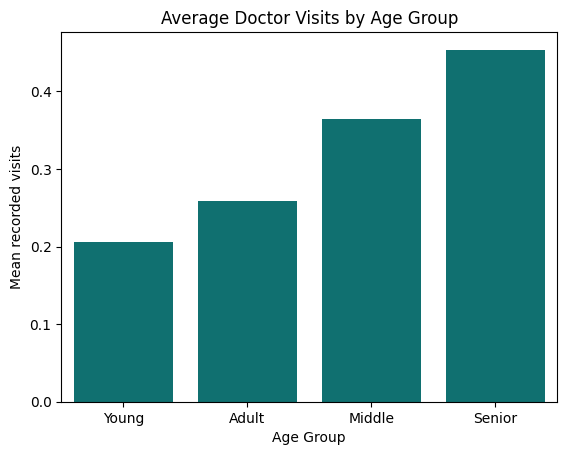

In [61]:
df["age_group"] = pd.cut(df["age"], bins=[0, 0.25, 0.45, 0.65, 0.8],
                         labels=["Young", "Adult", "Middle", "Senior"])

age_analysis = (
    df.groupby("age_group", observed=True)["visits"]
      .agg(["count", "mean"])
      .reset_index()
)

display(age_analysis)

sns.barplot(data=age_analysis, x="age_group", y="mean", color="teal")
plt.title("Average Doctor Visits by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Mean recorded visits")
plt.show()

###Average Doctor Visits by Income Group

,income_group,count,mean
0,Low,1638,0.398046
1,Lower-Mid,1329,0.305493
2,Upper-Mid,1485,0.230303
3,High,738,0.224932


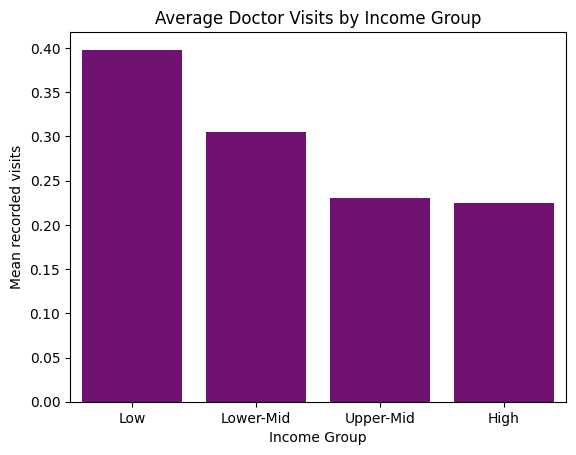

In [62]:
df["income_group"] = pd.qcut(df["income"], 4,
                             labels=["Low", "Lower-Mid", "Upper-Mid", "High"],
                             duplicates="drop")

income_analysis = (
    df.groupby("income_group", observed=True)["visits"]
      .agg(["count", "mean"])
      .reset_index()
)

display(income_analysis)

sns.barplot(data=income_analysis, x="income_group", y="mean", color="purple")
plt.title("Average Doctor Visits by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Mean recorded visits")
plt.show()

###Insurance type affect doctor visits

,private,count,mean
0,no,2892,0.307400
1,yes,2298,0.294604


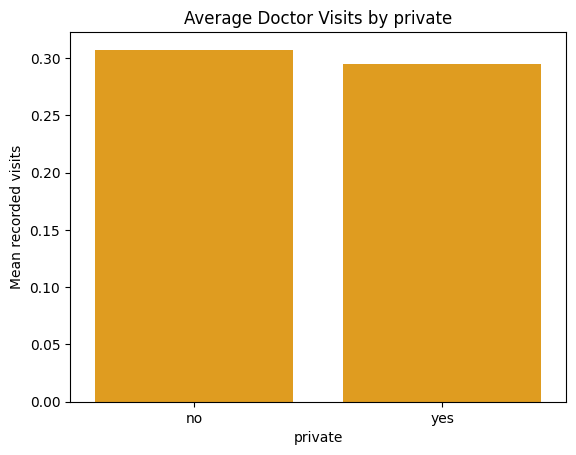

,freepoor,count,mean
0,no,4968,0.308172
1,yes,222,0.157658


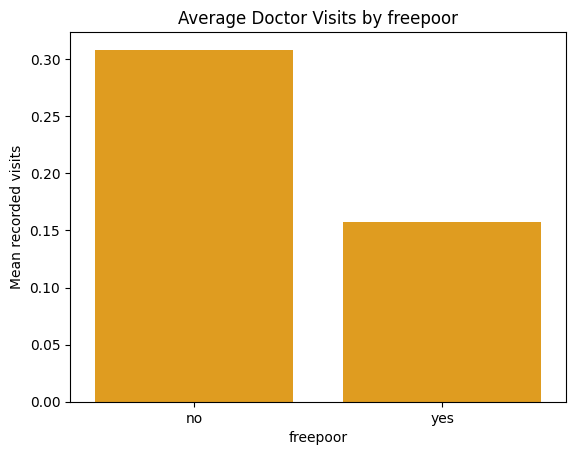

,freerepat,count,mean
0,no,4099,0.257868
1,yes,1091,0.466544


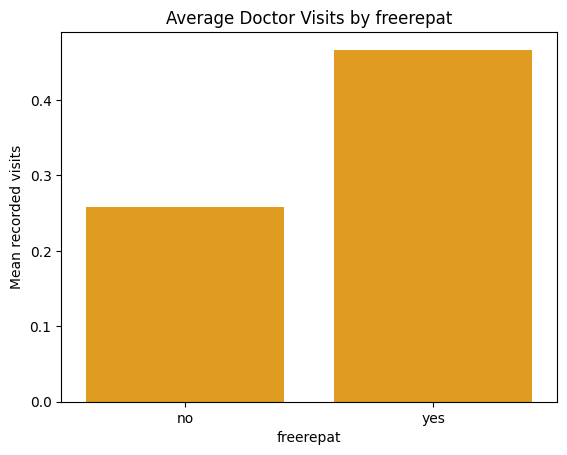

In [63]:
for col in ["private", "freepoor", "freerepat"]:
    result = df.groupby(col)["visits"].agg(["count", "mean"]).reset_index()
    display(result)

    sns.barplot(data=result, x=col, y="mean", color="orange")
    plt.title("Average Doctor Visits by " + col)
    plt.xlabel(col)
    plt.ylabel("Mean recorded visits")
    plt.show()

###People with chronic conditions visit more

,nchronic,count,mean
0,no,3098,0.272111
1,yes,2092,0.345602


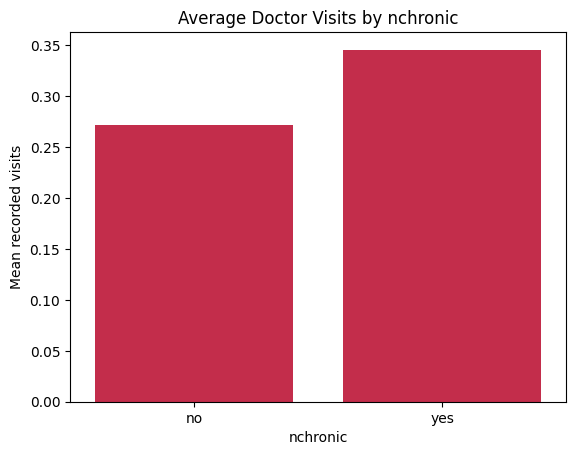

,lchronic,count,mean
0,no,4585,0.261941
1,yes,605,0.603306


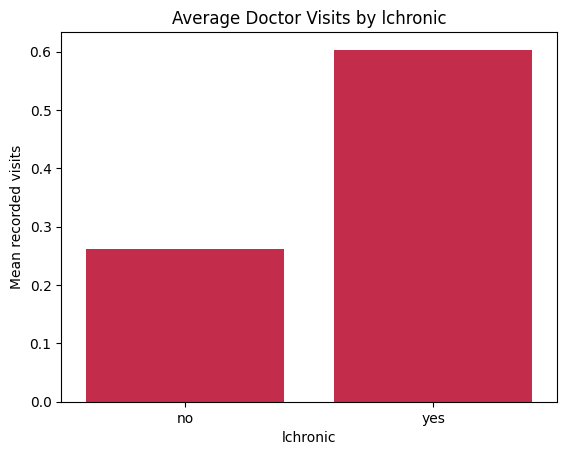

In [64]:
for col in ["nchronic", "lchronic"]:
    result = df.groupby(col)["visits"].agg(["count", "mean"]).reset_index()
    display(result)

    sns.barplot(data=result, x=col, y="mean", color="crimson")
    plt.title("Average Doctor Visits by " + col)
    plt.xlabel(col)
    plt.ylabel("Mean recorded visits")
    plt.show()

###Reduced Activity Days vs. Average Doctor Visits

,reduced,count,mean
0,0,4454,0.183880
1,1,177,0.355932
2,2,108,0.574074
3,3,74,1.094595
4,4,45,0.800000
5,5,40,1.275000
6,6,17,1.176471
7,7,38,1.184211
8,8,17,1.176471
9,9,7,1.714286


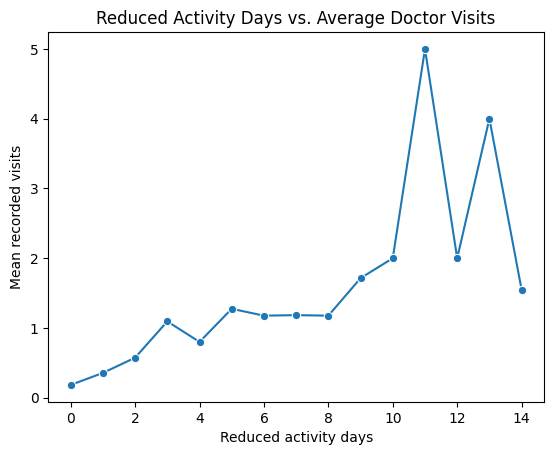

In [65]:
reduced_analysis = (
    df.groupby("reduced")["visits"]
      .agg(["count", "mean"])
      .reset_index()
)

display(reduced_analysis)

sns.lineplot(data=reduced_analysis, x="reduced", y="mean", marker="o")
plt.title("Reduced Activity Days vs. Average Doctor Visits")
plt.xlabel("Reduced activity days")
plt.ylabel("Mean recorded visits")
plt.show()

###Health Score vs. Average Doctor Visits

,health,count,mean
0,0,3026,0.199273
1,1,823,0.335358
2,2,446,0.381166
3,3,273,0.417582
4,4,187,0.534759
5,5,132,0.530303
6,6,104,0.625000
7,7,61,0.918033
8,8,42,0.476190
9,9,32,0.656250


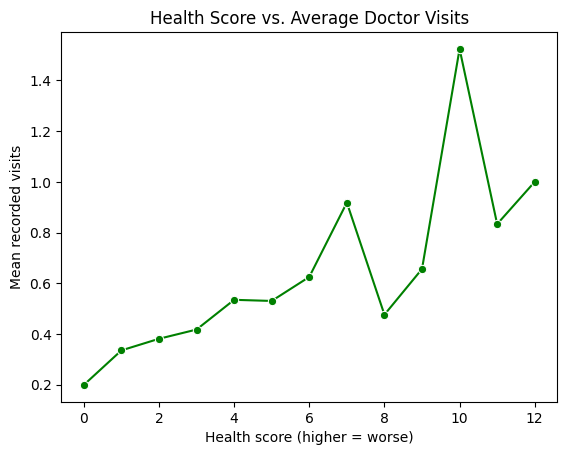

In [66]:
health_analysis = (
    df.groupby("health")["visits"]
      .agg(["count", "mean"])
      .reset_index()
)

display(health_analysis)

sns.lineplot(data=health_analysis, x="health", y="mean", marker="o", color="green")
plt.title("Health Score vs. Average Doctor Visits")
plt.xlabel("Health score (higher = worse)")
plt.ylabel("Mean recorded visits")
plt.show()

##Multivariate analysis

##Visits by gender

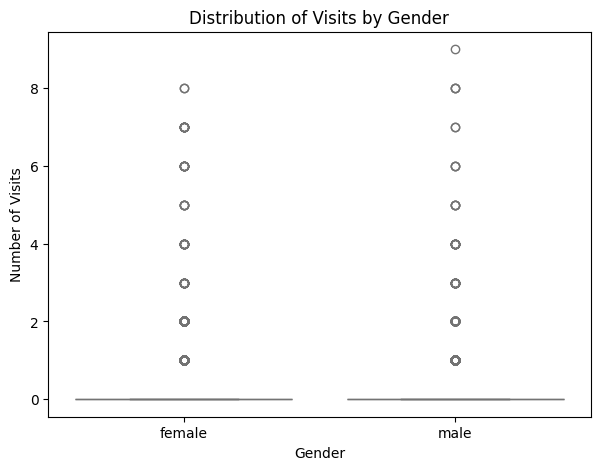

In [35]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='gender', y='visits', data=df, palette='pastel', hue='gender', legend=False)
plt.title('Distribution of Visits by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Visits')
plt.show()

##Age, visits and gender

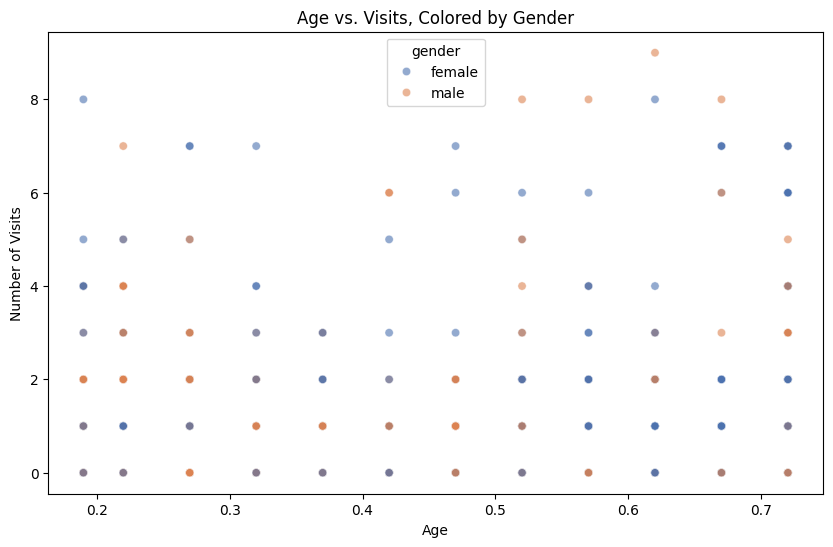

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='visits', hue='gender', data=df, palette='deep', alpha=0.6)
plt.title('Age vs. Visits, Colored by Gender')
plt.xlabel('Age')
plt.ylabel('Number of Visits')
plt.show()

##Factors are most related to doctor visits

visits     1.000000
reduced    0.418954
illness    0.223552
health     0.193272
age        0.124537
income    -0.076840
Name: visits, dtype: float64


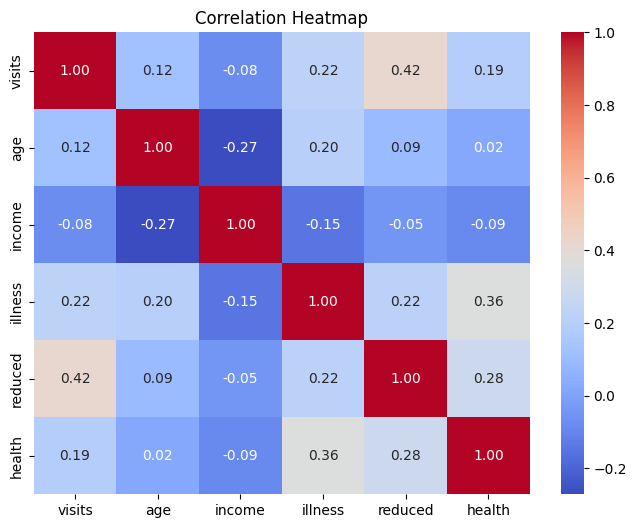

In [67]:
num_cols = df[["visits", "age", "income", "illness", "reduced", "health"]]

print(num_cols.corr()["visits"].sort_values(ascending=False))

plt.figure(figsize=(8, 6))
sns.heatmap(num_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

##Who are the high users (2 or more visits)

In [68]:
df["high_user"] = (df["visits"] >= 2).astype(int)

high_user_profile = df.groupby("high_user")[["age", "income", "illness", "reduced", "health"]].mean()
display(high_user_profile)

print("High users:", df["high_user"].sum(), "out of", len(df))

,age,income,illness,reduced,health
high_user,,,,,
0,0.403148,0.588306,1.377006,0.645135,1.140768
1,0.466067,0.488277,2.445693,4.857678,2.632959


High users: 267 out of 5190


##Do men and women differ when they have a limiting chronic condition?

lchronic,no,yes
gender,,
female,0.314141,0.694118
male,0.206478,0.486792


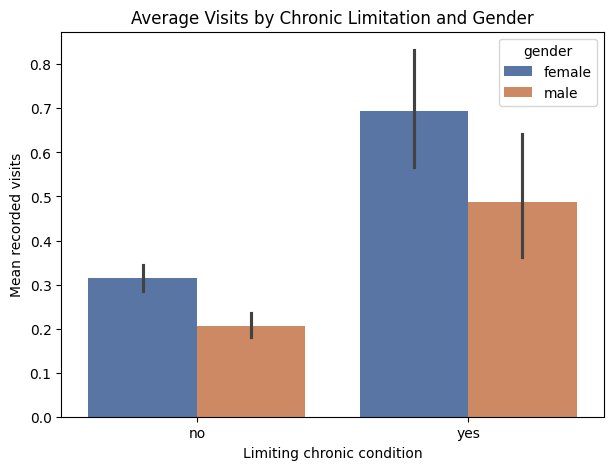

In [69]:
display(df.pivot_table(values="visits", index="gender", columns="lchronic", aggfunc="mean"))

plt.figure(figsize=(7, 5))
sns.barplot(data=df, x="lchronic", y="visits", hue="gender", palette="deep")
plt.title("Average Visits by Chronic Limitation and Gender")
plt.xlabel("Limiting chronic condition")
plt.ylabel("Mean recorded visits")
plt.show()

##Findings

## Data quality
- The dataset has 5,190 rows and 12 columns, with **no missing values**.
- **1,320 rows (25.43%)** are duplicates. They were kept because 1,795 of the 1,894 duplicated rows (95%) have 0 visits, so they are healthy people giving identical answers.
- Dropping the duplicates would raise mean visits from **0.302 to 0.389**, so removing them would overstate utilization.

## Univariate analysis
- **Gender:** the sample is fairly balanced, with 2,702 females (52%) and 2,488 males (48%).
- **Age:** ages (scaled age/100) run from 0.19 to 0.72, with a median of 0.32. A quarter of respondents are 0.22 or younger and a quarter are 0.62 or older.
- **Doctor visits:** the distribution is heavily right-skewed. The mean is 0.30, the median and the 75th percentile are both 0, and the maximum is 9.
- **Visited vs not visited:** 4,141 people (**79.8%**) had no visit and 1,049 (**20.2%**) had at least one. Most visits come from a small group.

## Bivariate analysis
- **Gender:** females average 0.36 visits and males 0.24, so women visit about 53% more. The median is 0 for both.
- **Illness score:** visits rise steadily, from **0.08** (0 illnesses) to **0.81** (5 illnesses). That is roughly a 10-fold increase.
- **Age group:** visits rise with age: Young 0.21, Adult 0.26, Middle 0.36, Senior 0.45. Seniors visit about **2.2 times** as often as the young.
- **Income group:** lower income means more visits: Low 0.40, Lower-Mid 0.31, Upper-Mid 0.23, High 0.22. The two top groups are almost the same.
- **Private insurance:** there is almost no difference (0.295 with it vs 0.307 without).
- **Free poor cover:** holders visit **less** (0.16 vs 0.31), but the group is small (n = 222). This could be an access gap, or just a small-sample effect.
- **Free repatriation cover:** holders visit **more** (0.47 vs 0.26), likely because they have more illness.
- **Chronic condition without limitation (`nchronic`):** only a small increase (0.35 vs 0.27).
- **Chronic condition with limitation (`lchronic`):** visits more than double (**0.60 vs 0.26**, about 2.3 times).
- **Reduced-activity days:** visits climb from 0.18 at 0 days to about 1.5 at 14 days. The line is jagged at the high end because a few days have very few people (for example 11 days has only 2 people).
- **Health score:** visits generally rise as the score gets worse, from 0.20 at 0 to about 1.0 or more at scores of 10 and above. Some points jump around because of small groups at the high end.

## Multivariate analysis
- **Boxplot by gender:** both genders have a median of 0 visits. Most of the spread comes from outliers, with a few people reaching several visits.
- **Age vs visits by gender (scatter plot):** visits are stacked at low whole numbers, so the plot shows the pattern but little detail. The overall trend is a slight rise with age.
- **Correlation with visits:**
  - `reduced`: 0.42, the strongest by far
  - `illness`: 0.22
  - `health`: 0.19
  - `age`: 0.12
  - `income`: -0.08 (weakly negative)
- **High users (2+ visits):** 267 people (5.1%). Compared with everyone else they are:
  - older (0.47 vs 0.40)
  - lower income (0.49 vs 0.59)
  - more illnesses (2.4 vs 1.4)
  - far more reduced-activity days (**4.9 vs 0.6**, about 7.5 times)
  - a worse health score (2.6 vs 1.1)
- **Gender and limiting chronic condition:** women visit more than men in both groups. Without a limiting condition it is 0.31 for women and 0.21 for men, and with one it is **0.69 vs 0.49**. Women with a limiting chronic condition are the highest group.

##Conclusion

The analysis shows that health need is the main factor influencing doctor visits. Reduced-activity days, number of illnesses, health score, and limiting chronic conditions have the strongest relationship with healthcare utilization. People with limiting chronic conditions tend to have approximately twice the visit rate.

Healthcare utilization is also highly concentrated: around 80% of people had no doctor visit, while the small group with two or more visits accounted for about half of all visits. Women, older people, and lower-income groups reported more visits, partly reflecting their higher levels of reported illness. Insurance type, particularly private insurance, showed relatively little difference in the number of visits.

Therefore, healthcare planning should give greater attention to people with limiting chronic conditions and frequent reduced-activity days, while also considering the needs of older and lower-income populations.